# Project 2: Exploratory Data Analysis (EDA) Report
---
## Assigned Topic:
__World Development Statistics__

## Selected Problem Statement: 
__Targeted Funding for "Hollow Growth" Regions__

## 1. Introduction & Objectives
Top-level economic growth often masks underlying crises, such as rapid population expansion diluting wealth or rising incomes failing to improve life expectancy. The Policy Steering Committee needs to analyze historical population, GNI per capita, and life expectancy trends (1960-2020) to identify nations trapped in these hollow growth cycles. Pinpointing these disconnects will allow the agency to accurately target a $100M intervention fund to countries suffering from stalled human development.

### 1.1 Context & Background
Economic growth does not always lead to improvements in human development, particularly when rapid population growth limits the impact of rising national income. This project analyzes historical population, GNI per capita, and life expectancy data (1960–2020) to identify countries experiencing "hollow growth." The findings support evidence-based recommendations for allocating the proposed $100 million intervention fund to countries with stalled human development.
### 1.2 Core Analytical Objectives

* Cleaning and dealing with missing values prevent any biasing
* Analysing the historical trend and finding increments relations
* Filtering and summarizing data
* Identification of hollow growth countries
* Results validation
* Policy recommendation


---

## 2. Environment Setup & Data Collection

In [2]:
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
gni=pd.read_csv('./data/gni_per_cap_atlas_method_con2021.csv')
life_exp=pd.read_csv('./data/life_expectancy.csv')
population=pd.read_csv('./data/population.csv')

---
## 3. Data Handling


In [4]:
gni_long=pd.melt(frame=gni,id_vars='country',var_name='year',value_name='gni')
life_exp_long=pd.melt(frame=life_exp,id_vars='country',var_name='year',value_name='life_exp')
population_long=pd.melt(frame=population,id_vars='country',var_name='year',value_name='population')


In [5]:
print(gni_long.shape)
print(life_exp_long.shape)
print(population_long.shape)

(47941, 3)
(58695, 3)
(59297, 3)


In [6]:
print(gni_long.isna().sum())
print(life_exp_long.isna().sum())
print(population_long.isna().sum())

country      0
year         0
gni        229
dtype: int64
country        0
year           0
life_exp    2079
dtype: int64
country         0
year            0
population    100
dtype: int64


In [7]:
print(gni_long.dtypes)
print(life_exp_long.dtypes)
print(population_long.dtypes)

country       str
year          str
gni        object
dtype: object
country         str
year            str
life_exp    float64
dtype: object
country       str
year          str
population    str
dtype: object


In [8]:
gni_countries = set( gni_long['country'] )
life_countries = set( life_exp_long['country'] )
pop_countries = set( population_long['country'] )

missing_in_gni_but_in_pop = pop_countries - gni_countries
missing_in_life_but_in_pop = pop_countries - life_countries

print("In Population but missing in GNI:", missing_in_gni_but_in_pop)
print("In Population but missing in life expextency:", missing_in_life_but_in_pop)

In Population but missing in GNI: {'Taiwan', 'Monaco', 'San Marino', 'Andorra', 'Holy See', 'North Korea'}
In Population but missing in life expextency: {'Holy See', 'Liechtenstein'}


---
**Converting the years to integres:**

In [9]:
population_long['year']=population_long['year'].astype(int)
gni_long['year']=gni_long['year'].astype(int)
life_exp_long['year']=life_exp_long['year'].astype(int)

---
**Creating functions to covert the gni and populations into numbers:**

In [10]:
def convert_gni_num(x):
    
    value= str(x['gni'])
    
    if 'M' in value:
        y=value.strip('M')
        return float(y)*1000000
    elif 'k' in value:
        y=value.strip('k')
        return float(y)*1000
    else:
        return float(value)

def convert_pop_num(x):
    
    value= str(x['population'])
    
    if 'B' in value:
        y=value.strip('B')
        return float(y)*1000000000
    elif 'M' in value:
        y=value.strip('M')
        return float(y)*1000000
    elif 'k' in value:
        y=value.strip('k')
        return float(y)*1000
    else:
        return float(value)

In [11]:
population_long['population']=population_long.apply(convert_pop_num,axis=1)
gni_long['gni']=gni_long.apply(convert_gni_num,axis=1)

---
**Handiling tables from any null values:**

In [12]:
population_long[(population_long['population'].isna())].sort_values('year').head()

,country,year,population
39671,Holy See,2001,NaN
39868,Holy See,2002,NaN
40065,Holy See,2003,NaN
40262,Holy See,2004,NaN
40459,Holy See,2005,NaN


**Noticing that population null values are all missing values from Holy See between 2001 --> 2100.**

---

In [13]:
life_exp_long[(life_exp_long['life_exp'].isna())].sort_values('year')

,country,year,life_exp
3,Andorra,1800,NaN
46,Dominica,1800,NaN
93,St. Kitts and Nevis,1800,NaN
107,Monaco,1800,NaN
112,Marshall Islands,1800,NaN
...,...,...,...
58612,Marshall Islands,2100,NaN
58631,Nauru,2100,NaN
58638,Palau,2100,NaN
58656,San Marino,2100,NaN


**Noticing that there are (9) countries are repeated and have null life expextance values,\
except for years from 1950 unti 2019**

In [14]:
exluded_life_countries=['Andorra','Dominica','St. Kitts and Nevis','Monaco','Marshall Islands','Nauru','Palau','San Marino','Tuvalu']

---
**Double checking there are no missing values other from the exluded countries:**

In [15]:
life_exp_long[(~life_exp_long['country'].isin(exluded_life_countries)) & (life_exp_long['life_exp'].isna())]

,country,year,life_exp


In [16]:
gni_long[(gni_long['gni'].isna())].sort_values('year').head()

,country,year,gni
100,Liechtenstein,1800,NaN
291,Liechtenstein,1801,NaN
482,Liechtenstein,1802,NaN
673,Liechtenstein,1803,NaN
864,Liechtenstein,1804,NaN


**Noticing that Liechtenstein always had nulll values in the GNI.**

---
**Joining the 3 tables**

In [17]:
pop_life=pd.merge(left=population_long, 
                  right=life_exp_long,
                  how='left',
                  on=(['country','year']))
pop_life_gni=pd.merge(left=pop_life,
                      right=gni_long,
                      how='left',
                      on=(['country','year']))

In [18]:
pop_life_gni.isna().sum()

country           0
year              0
population      100
life_exp       2681
gni           11585
dtype: int64

---
**Dropping null values, because we were not able to fill the missing values in population, life expectence and gni tables.\
Also, it will be safe approch since there is no relation between merged table missing values**

In [19]:
cleaned_pop_life_gni=pop_life_gni.dropna(subset=['gni', 'life_exp', 'population'])

---
**Perecentage of kept data:**

In [20]:
print(f"Original data set size: {len(pop_life_gni)}")
print(f"After Drop data set size: {len(cleaned_pop_life_gni)}")
print(f"Percentage of data retained: {len(cleaned_pop_life_gni)/len(pop_life_gni)*100:.1f}%")

Original data set size: 59297
After Drop data set size: 46604
Percentage of data retained: 78.6%


---
## 4. Exploratory Data Analysis (EDA)


### 4.1. Visualising Correlation Between Population, GNI per Capita, and Life Expectancy

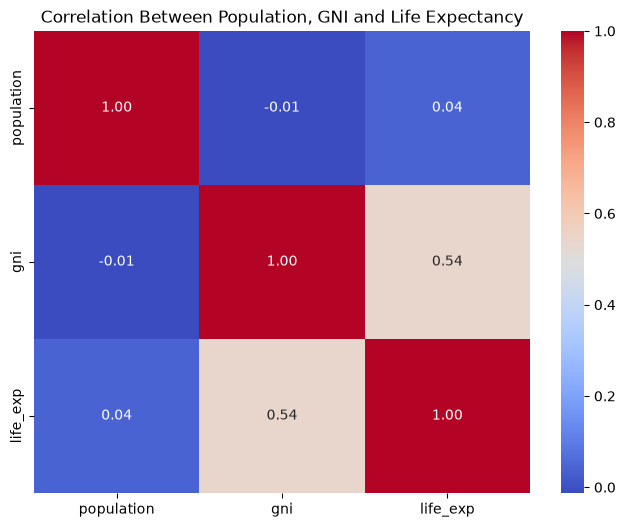

In [21]:
corr = cleaned_pop_life_gni.loc[(cleaned_pop_life_gni['year']>=1960) & (life_exp_long['year']<=2020),['population','gni','life_exp']].corr()
plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Population, GNI and Life Expectancy")
plt.show()

**As it appears, 54% of the times gni growth is translated to increasment in the life expextancy. While there is poor relation betwwen the incresment in the life expectancy.**

### 4.2. Summarizing The Data

In [22]:

summary=pd.DataFrame()
summary['year_start'] = cleaned_pop_life_gni.groupby('country')['year'].first()
summary['year_end'] = cleaned_pop_life_gni.groupby('country')['year'].last()
summary['population_start'] = cleaned_pop_life_gni.groupby('country')['population'].first()
summary['population_end'] = cleaned_pop_life_gni.groupby('country')['population'].last()
summary['life_exp_start'] = cleaned_pop_life_gni.groupby('country')['life_exp'].first()
summary['life_exp_end'] = cleaned_pop_life_gni.groupby('country')['life_exp'].last()
summary['gni_start'] = cleaned_pop_life_gni.groupby('country')['gni'].first()
summary['gni_end'] = cleaned_pop_life_gni.groupby('country')['gni'].last()
summary=summary.reset_index()
summary.head()

,country,year_start,year_end,population_start,population_end,life_exp_start,life_exp_end,gni_start,gni_end
0,Afghanistan,1800,2050,3280000.0,74100000.0,28.2,70.0,207.0,907.0
1,Albania,1800,2050,400000.0,2460000.0,35.4,82.8,207.0,11600.0
2,Algeria,1800,2050,2500000.0,60000000.0,28.8,81.2,446.0,5370.0
3,Angola,1800,2050,1570000.0,72300000.0,27.0,73.1,517.0,3340.0
4,Antigua and Barbuda,1800,2050,37000.0,99000.0,33.5,80.2,650.0,26900.0


---
**Checking data:**

In [23]:
summary[(summary['year_start']<=1960) & (summary['year_end']<=2019)]

,country,year_start,year_end,population_start,population_end,life_exp_start,life_exp_end,gni_start,gni_end
47,Dominica,1950,2019,50200.0,71400.0,49.3,72.3,1060.0,8410.0
105,Marshall Islands,1950,2019,13100.0,44700.0,52.1,65.5,1790.0,5150.0
117,Nauru,1950,2019,3350.0,12100.0,58.5,63.4,5700.0,16900.0
128,Palau,1950,2019,7430.0,17900.0,49.0,67.5,9400.0,17000.0
158,St. Kitts and Nevis,1950,2019,47300.0,47700.0,60.8,72.1,2070.0,21600.0
176,Tuvalu,1950,2019,4730.0,11000.0,47.0,67.9,1870.0,5730.0


---
**6 countires has missing values on 2020.\
So, I will be calculate the last 3 years average and added to year 2020**

In [24]:
edge_countries=['Dominica','St. Kitts and Nevis','Marshall Islands','Nauru','Palau','Tuvalu']

In [26]:
edge_data = cleaned_pop_life_gni[
    (cleaned_pop_life_gni['country'].isin(edge_countries)) & 
    (cleaned_pop_life_gni['year'].isin([2017, 2018, 2019]))]

average_edge_data=edge_data.groupby('country')[['population','life_exp','gni']].mean()
average_edge_data

last_year_edge_data=cleaned_pop_life_gni[
    (cleaned_pop_life_gni['country'].isin(edge_countries)) & 
    (cleaned_pop_life_gni['year']==2019)].set_index('country')[['gni', 'life_exp', 'population']]


new_edge_data=(last_year_edge_data+(last_year_edge_data-average_edge_data)).reset_index()
new_edge_data['year']=2020

cleaned_pop_life_gni = pd.concat([cleaned_pop_life_gni, new_edge_data], ignore_index=True)
cleaned_pop_life_gni = cleaned_pop_life_gni.drop_duplicates(subset=['country', 'year'], keep='first')
cleaned_pop_life_gni.to_csv('cleaned_pop_life_gni.csv',index=False)

In [27]:
updated_cleaned_pop_life_gni=cleaned_pop_life_gni[(cleaned_pop_life_gni['year']>=1960) & (cleaned_pop_life_gni['year']<=2020)]
updated_summary=pd.DataFrame()
updated_summary['year_start'] =updated_cleaned_pop_life_gni.groupby('country')['year'].first()
updated_summary['year_end'] =updated_cleaned_pop_life_gni.groupby('country')['year'].last()
updated_summary['population_start'] = updated_cleaned_pop_life_gni.groupby('country')['population'].first()
updated_summary['population_end'] = updated_cleaned_pop_life_gni.groupby('country')['population'].last()
updated_summary['life_exp_start'] = updated_cleaned_pop_life_gni.groupby('country')['life_exp'].first()
updated_summary['life_exp_end'] = updated_cleaned_pop_life_gni.groupby('country')['life_exp'].last()
updated_summary['gni_start'] = updated_cleaned_pop_life_gni.groupby('country')['gni'].first()
updated_summary['gni_end'] = updated_cleaned_pop_life_gni.groupby('country')['gni'].last()
updated_summary=updated_summary.reset_index()
updated_summary.sort_values('gni_end',ascending=False).head()
updated_summary.to_csv('updated_summary.csv',index=False)

### 4.3. Visualising the overall life expectancy, GNI and population trend

In [27]:
avg_life=life_exp_long[(life_exp_long['year']>=1960) & (life_exp_long['year']<=2020)].groupby('year')['life_exp'].mean()
avg_population=population_long[(population_long['year']>=1960) & (population_long['year']<=2020)].groupby('year')['population'].mean()
avg_gni=gni_long[(gni_long['year']>=1960) & (gni_long['year']<=2020)].groupby('year')['gni'].mean()

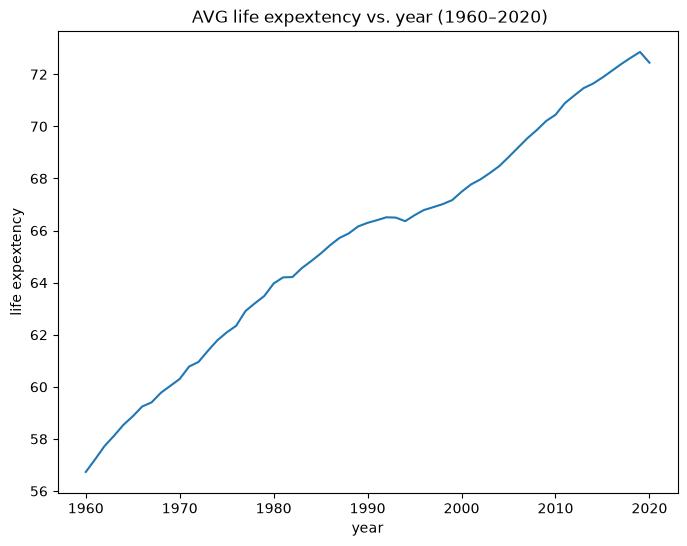

In [28]:
avg_life.plot(ylabel='life expextency', title=' AVG life expextency vs. year (1960–2020)',figsize=(8,6));

**For the average life expectancy trend line, it shows continuous Increase without major decrease.**

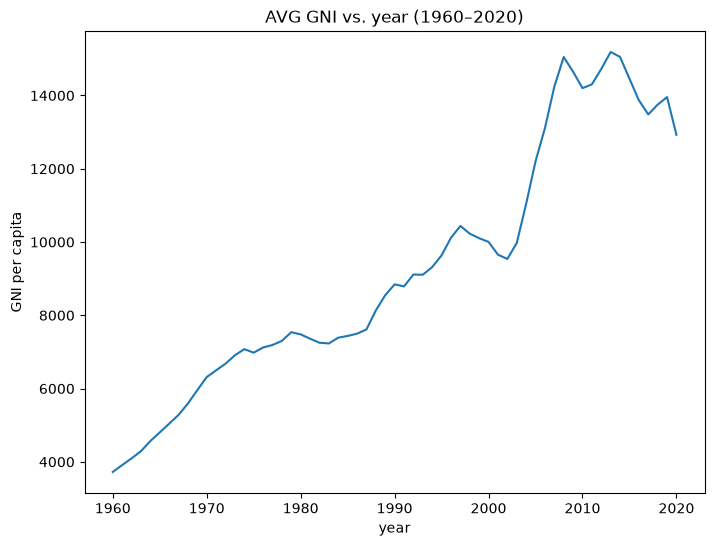

In [29]:
avg_gni.plot(ylabel='GNI per capita', title='AVG GNI vs. year (1960–2020)',figsize=(8,6));

**The overall average GNI per capita trend is upward, but it experiences frequent, sharp reversals and downturns.**

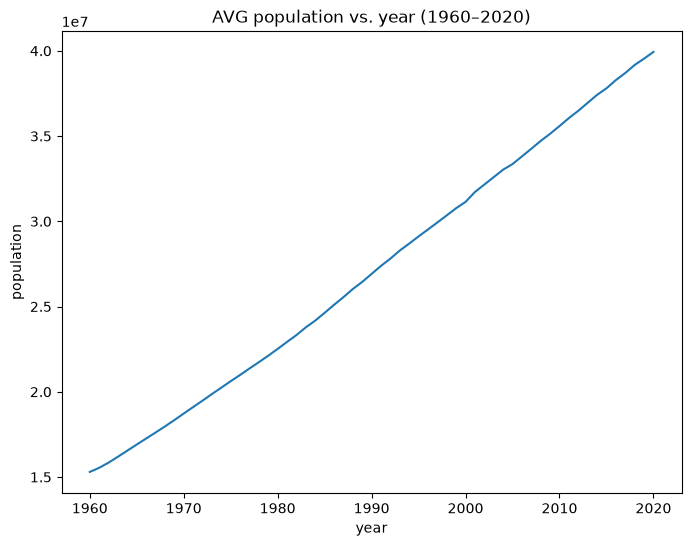

In [30]:
avg_population.plot(ylabel='population',title='AVG population vs. year (1960–2020)',figsize=(8,6));


**The overall population has stead upward trend.**

### 4.4. Visualising the relation between population, GNI per capita growth rates with the life expectency gain

In [31]:
updated_summary['pop_growth']=round(((updated_summary['population_end']-updated_summary['population_start'])/updated_summary['population_start']),2)
updated_summary['life_exp_gain']=round((updated_summary['life_exp_end']-updated_summary['life_exp_start']),2)
updated_summary['gni_growth']=round(((updated_summary['gni_end']-updated_summary['gni_start'])/updated_summary['gni_start']),2)
updated_summary.head()

,country,year_start,year_end,population_start,population_end,life_exp_start,life_exp_end,gni_start,gni_end,pop_growth,life_exp_gain,gni_growth
0,Afghanistan,1960,2020,8620000.0,39000000.0,45.0,63.4,469.0,500.0,3.52,18.4,0.07
1,Albania,1960,2020,1710000.0,2870000.0,62.5,77.9,736.0,5210.0,0.68,15.4,6.08
2,Algeria,1960,2020,11400000.0,43500000.0,52.4,76.2,3670.0,3570.0,2.82,23.8,-0.03
3,Angola,1960,2020,5360000.0,33400000.0,46.3,65.2,1720.0,2140.0,5.23,18.9,0.24
4,Antigua and Barbuda,1960,2020,55300.0,92700.0,63.8,76.3,2790.0,13800.0,0.68,12.5,3.95


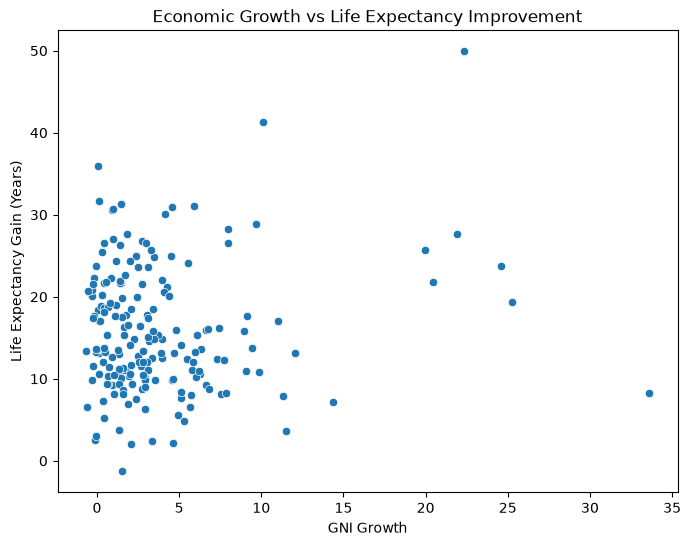

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=updated_summary,
    x="gni_growth",
    y="life_exp_gain")

plt.title("Economic Growth vs Life Expectancy Improvement")
plt.xlabel("GNI Growth")
plt.ylabel("Life Expectancy Gain (Years)")

plt.show()

**From the scatter plot of Economic Growth vs Life Expectancy Improvement,\
it validate the statement of having growth in the GNI is not always translated to better live.**

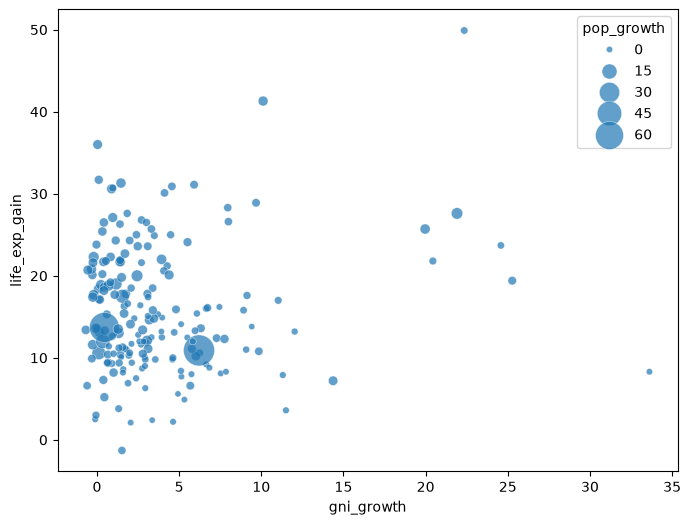

In [33]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=updated_summary,
    x="gni_growth",
    y="life_exp_gain",
    size="pop_growth",
    sizes=(20,500),
    alpha=0.7
);

**From the scatter plot of Economic Growth vs Life Expectancy Improvement,\
it validate the statement of having growth in the GNI is not always translated to better live.**

In [40]:
top_gni_growth=updated_summary.sort_values('gni_growth',ascending=False).head(5)
top_life_exp_gain=updated_summary.sort_values('life_exp_gain',ascending=False).head(5)
top_pop_growth=updated_summary.sort_values('pop_growth',ascending=False).head(5)

top_gni_growth.to_csv('top_gni_growth.csv',index=False)
top_pop_growth.to_csv('top_pop_growth.csv',index=False)
top_life_exp_gain.to_csv('top_life_exp_gain.csv',index=False)

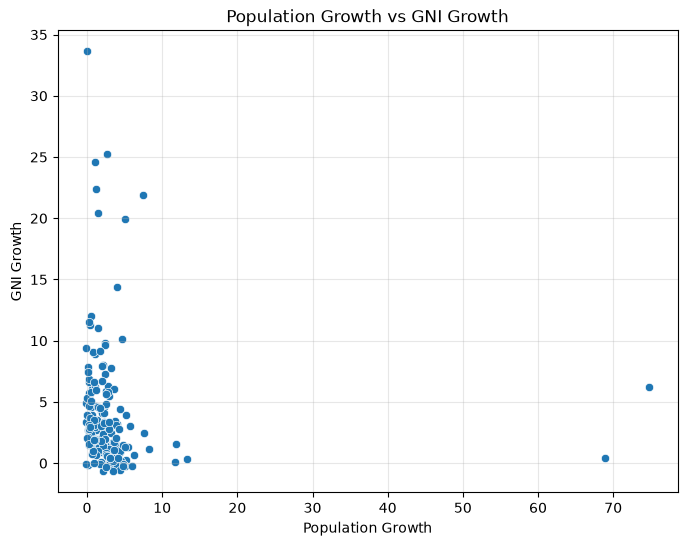

In [73]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=updated_summary,
    x='pop_growth',
    y='gni_growth'
)

plt.title("Population Growth vs GNI Growth")
plt.xlabel("Population Growth")
plt.ylabel("GNI Growth")

plt.grid(alpha=0.3)
plt.show()

**From the scatter plot, it shows that there very week relation between gni growth and population growth.**

In [38]:
updated_summary[['gni_growth', 'pop_growth', 'life_exp_gain']].describe()

,gni_growth,pop_growth,life_exp_gain
count,190.000000,190.000000,190.000000
mean,3.830053,3.096053,15.787947
std,4.960800,7.426849,7.727380
min,-0.680000,-0.160000,-1.300000
25%,0.937500,0.680000,10.425000
50%,2.495000,2.125000,13.950000
75%,4.900000,3.507500,20.675000
max,33.620000,74.820000,49.900000


### 4.5. Identify Hollow Growth Countries

In [42]:
hollow_growth = updated_summary[
    (updated_summary["gni_growth"] >= 4.90) &
    (updated_summary["pop_growth"] >= 3.5075) &
    (updated_summary["life_exp_gain"] <= 10)
]
hollow_growth.to_csv('hollow_growth.csv',index=False)

### 4.6. Validating Hollow Growth Countries result

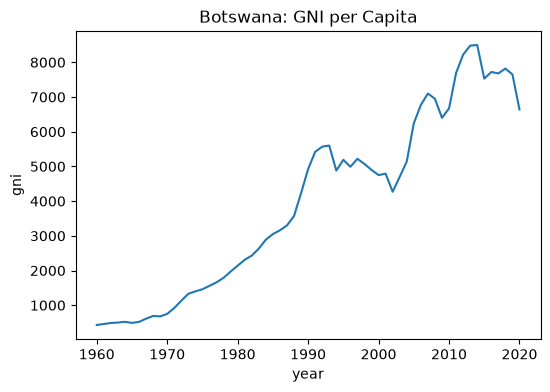

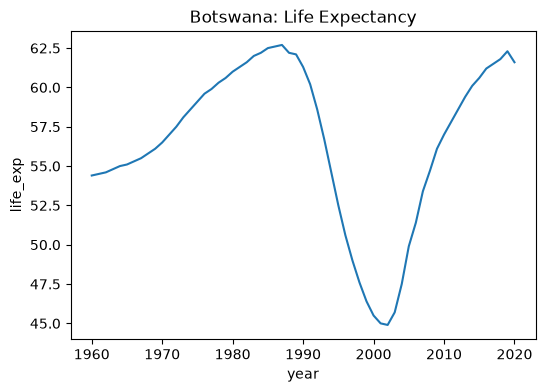

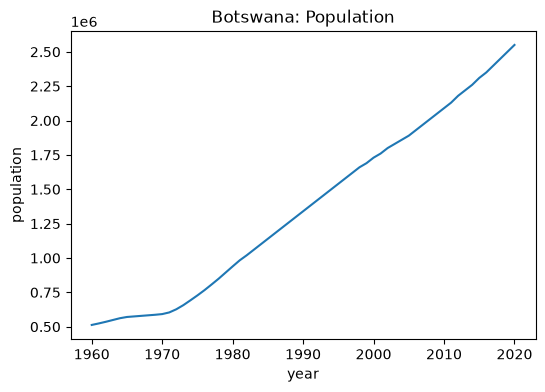

In [170]:

for country in hollow_growth["country"]:

    country_data = cleaned_pop_life_gni[(cleaned_pop_life_gni["country"] == country) & (cleaned_pop_life_gni['year']>=1960) & (cleaned_pop_life_gni['year']<=2020)]

    plt.figure(figsize=(6,4))
    sns.lineplot(data=country_data, x="year", y="gni")
    plt.title(f"{country}: GNI per Capita")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.lineplot(data=country_data, x="year", y="life_exp")
    plt.title(f"{country}: Life Expectancy")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.lineplot(data=country_data, x="year", y="population")
    plt.title(f"{country}: Population")
    plt.show()

**Combining historical trend of population,life expextancy and GNI for Botswana,\
it reinforce that Botswana suffers from stalled human development despite economic progress.**

---
## 5. Summary of Findings & Actionable Recommendations

### 5.1 Key Insights (Summary of Findings)

* High Economic growth does is not always translated into better lives. 
* By combining historical trend analysis, correlation analysis, and applying filtration methodology, the project successfully highlighted potential hollow-growth countries

### 5.2 Actionable Recommendations
* The project successfully highlighted potential hollow-growth countries, which in our case was Botswana. These findings provide the Policy Steering Committee with evidence-based candidates for the proposed $100 million intervention fund, ensuring that resources are directed toward countries experiencing stalled human development despite economic progress.

## 6. Data Dictionary & References

### 6.1 Data Dictionary
| Feature / Column | Data Type | Source | Description |
|:---|:---|:---|:---|
| country | string | Original  | country name specified  |
| year/year_start/year_end | integer | Engineered  | the year that data  was based on |
| population/population_start/population_end | float | Original / Engineered | country's population at the specified year |
| life_exp/life_exp_start/life_exp_end| float | Engineered | country's expected years to live for a person that borned at the specified |
| gni/gi_start/gni_end | float |  Engineered | country's Gross National Income divided by its mid-year population. It reflects the average income earned by each citizen |
| pop_growth | float | Engineered | country's ratio of the population in 2020 to the population in 1960.  |
| life_exp_gain | float |  Engineered | country's difference in life expectancy between 2020 and 1960.  |
| gni_growth | float | Engineered | country's ratio of the gni per capita in 2020 to the population in 1960.  |

### 6.2 References & Sources
* *https://www.gapminder.org/about/*